In [1]:
import nltk
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Load Data

In [2]:
# Load the data
df = pd.read_csv('/content/drive/MyDrive/email.csv')

In [3]:
# Print samples
df.sample(2)

,Category,Message
508,ham,You should know now. So how's anthony. Are you...
2447,ham,"Sorry, I'll call later"


#### Data cleaning

In [4]:
# Check for the null values
df.isnull().sum()

,0
Category,0
Message,0


In [5]:
# Check for the suplicated values
df.duplicated().sum()

415

In [6]:
# Drop the duplicate values
df = df.drop_duplicates(keep='first')

In [7]:
# Label encoding for the category coulumn
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Category'] = encoder.fit_transform(df['Category'])

<ipython-input-7-e8195ddef376>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Category'] = encoder.fit_transform(df['Category'])


In [8]:
# Remove the column which have Category value 2
df= df[df['Category'] != 2]

In [9]:
# New shape of the df
df.shape

(5157, 2)

#### EDA

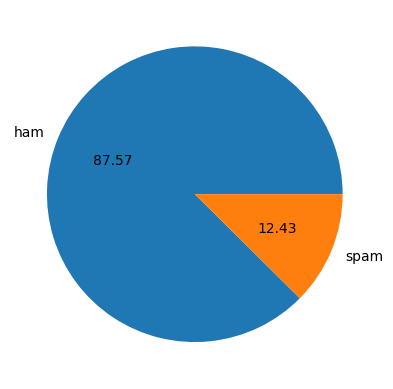

In [10]:
# Pie plot for showing the precentages of spam and ham
import matplotlib.pyplot as plt
plt.pie(df['Category'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [11]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [12]:
# Create a new column for number of chacters
df['num_characters'] = df['Message'].apply(len)

In [13]:
# Create a new column for number of words
df['num_words'] = df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [14]:
# Create a new column for number of sentences
df['num_sentences'] = df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [15]:
df.sample(1)

,Category,Message,num_characters,num_words,num_sentences
678,0,"Piggy, r u awake? I bet u're still sleeping. I...",69,20,3


In [16]:
df.describe()

,Category,num_characters,num_words,num_sentences
count,5157.000000,5157.000000,5157.000000,5157.000000
mean,0.124297,79.103936,18.560403,1.969750
std,0.329952,58.382922,13.405970,1.455526
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,61.000000,15.000000,1.000000
75%,0.000000,118.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


<Axes: >

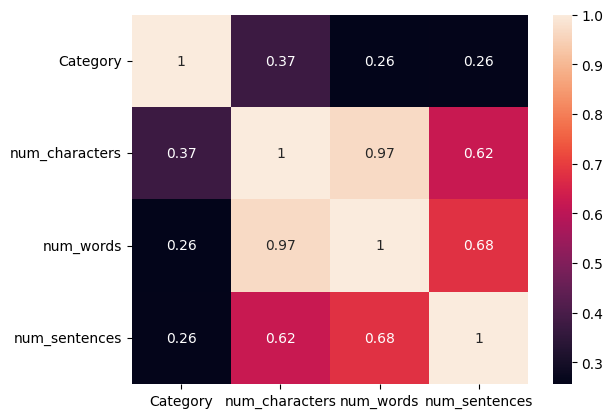

In [17]:
# see the correlations between the columns
temp_df = df.drop(['Message'],axis=1)
sns.heatmap(temp_df.corr(),annot=True)

There are multicollinearity between num_characters,num_words and num_sentences. Thus I keep only num_characters
bewteen them as it has strongest correlation with categrory.

In [18]:
# Drop two columns
df = df.drop(columns=['num_words', 'num_sentences'])

<Axes: xlabel='num_characters', ylabel='Count'>

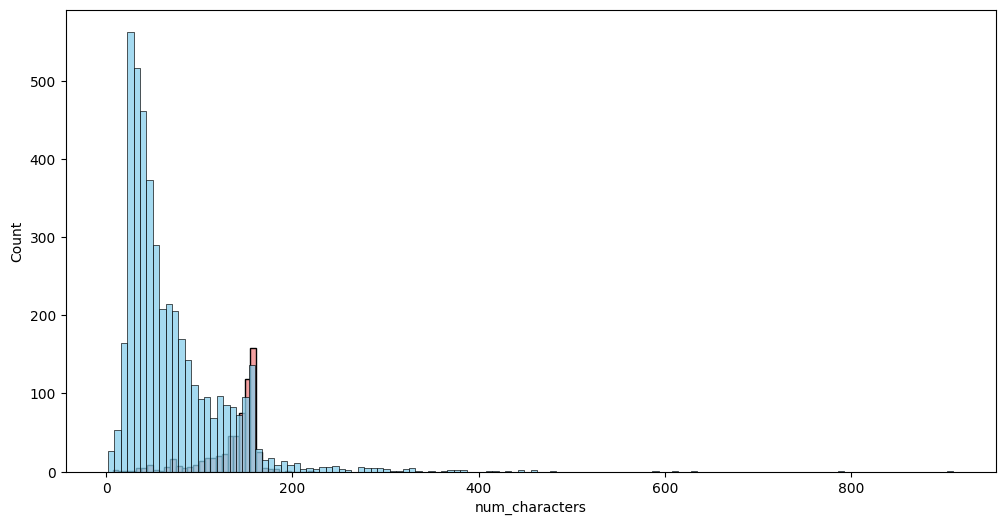

In [30]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['Category']==1]['num_characters'],color='lightcoral')
sns.histplot(df[df['Category']==0]['num_characters'],color='skyblue')

#### Data preprocessing


In [20]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [21]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    # Create an instance of PorterStemmer
    ps = PorterStemmer()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)


In [22]:
df['transformed_Message'] = df['Message'].apply(transform_text)

In [23]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [24]:
spam_wc = wc.generate(df[df['Category']==1]['transformed_Message'].str.cat(sep=''))

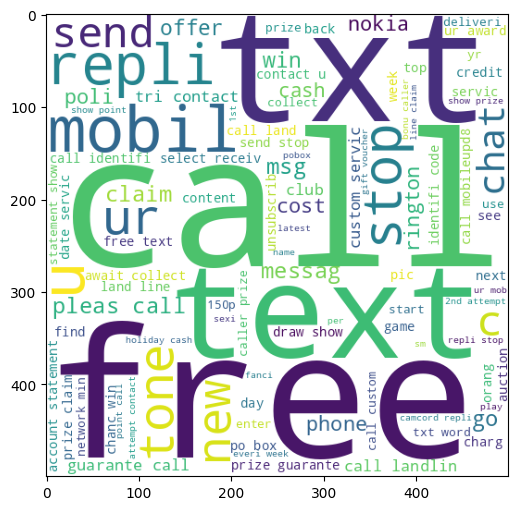

In [25]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

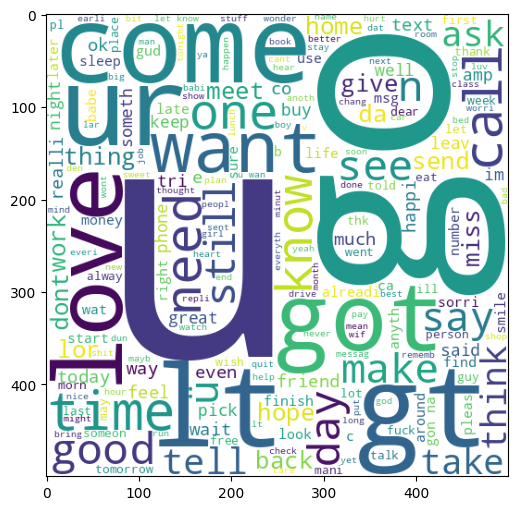

In [26]:
ham_wc = wc.generate(df[df['Category']==0]['transformed_Message'].str.cat(sep=''))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

#### Model Building

In [27]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=1000)

In [28]:
X = tfidf.fit_transform(df['transformed_Message']).toarray()

In [ ]:
y = df['Category'].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.7839147286821705
[[695 210]
 [ 13 114]]
0.35185185185185186


In [ ]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9815891472868217
[[905   0]
 [ 19 108]]
1.0


In [ ]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9825581395348837
[[903   2]
 [ 16 111]]
0.9823008849557522


In [ ]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import pandas as pd

# Assuming X_train, X_test, y_train, y_test are defined somewhere in your code

svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)

    print("For", name)
    print("Accuracy -", current_accuracy)
    print("Precision -", current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

performance_df = pd.DataFrame({'Algorithm': list(clfs.keys()), 'Accuracy': accuracy_scores, 'Precision': precision_scores}).sort_values('Precision', ascending=False)
print(performance_df)


For SVC
Accuracy - 0.9767441860465116
Precision - 0.9904761904761905
For KN
Accuracy - 0.9234496124031008
Precision - 1.0
For NB
Accuracy - 0.9815891472868217
Precision - 1.0
For DT
Accuracy - 0.937984496124031
Precision - 0.8888888888888888
For LR
Accuracy - 0.9651162790697675
Precision - 0.9504950495049505
For RF
Accuracy - 0.9728682170542635
Precision - 0.9714285714285714
For AdaBoost
Accuracy - 0.9641472868217055
Precision - 0.9326923076923077
For BgC
Accuracy - 0.9602713178294574
Precision - 0.9056603773584906
For ETC
Accuracy - 0.9748062015503876
Precision - 0.963302752293578
For GBDT
Accuracy - 0.9515503875968992
Precision - 0.9753086419753086
For xgb
Accuracy - 0.9718992248062015
Precision - 0.9711538461538461
   Algorithm  Accuracy  Precision
1         KN  0.923450   1.000000
2         NB  0.981589   1.000000
0        SVC  0.976744   0.990476
9       GBDT  0.951550   0.975309
5         RF  0.972868   0.971429
10       xgb  0.971899   0.971154
8        ETC  0.974806   0.963303


`Here, I find good scores for NB.`

In [ ]:
# Voting Classifier
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
mnb = MultinomialNB()
knc = KNeighborsClassifier()

from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[('rfc', rfc), ('nb', mnb), ('knn', knc)],voting='soft')

voting.fit(X_train,y_train)

y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9660852713178295
Precision 1.0


`Not better than Naive Bayes.`
`Now, applying stacking.`

In [ ]:
# Applying stacking
estimators=[('rfc', rfc), ('nb', mnb), ('knn', knc)]
final_estimator=RandomForestClassifier()

from sklearn.ensemble import StackingClassifier

clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9757751937984496
Precision 0.9322033898305084


`Not better than Naive Bayes.So, I'll use multinomial Naive Bayes.`

In [ ]:
# Initialize the Multinomial Naive Bayes classifier
clf = MultinomialNB()

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test,y_pred)


print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")



Accuracy: 0.9815891472868217
Precision: 1.0


In [ ]:
import joblib

# Assuming clf and tfidf are your trained classifier and vectorizer
# Save the model
joblib.dump(clf, 'email_classifier.pkl')

# Save the vectorizer
joblib.dump(tfidf, 'vectorizer.pkl')

['vectorizer.pkl']